# Descriptive Statistics with Python

For this exercise, we will be using the [Online Sales Dataset - Popular Marketplace Data](https://www.kaggle.com/datasets/shreyanshverma27/online-sales-dataset-popular-marketplace-data) from kaggle. We will learn how we can summarize and Describe the Data we have using Pandas and Matplotlib.

## Descriptive Statistics

Statistics is the science of planning studies and experiments; obtaining data; and organizing, summarizing, presenting, analyzing, and interpreting those data and then drawing conclusions based on them.

Descriptive statistics deals with methods for 
* Collecting
* Organizing
* and describing data 

by using 

* tables
* graphs 
* and summary measures.

### Importing the Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### Loading the CSV file as DataFrame

In [ ]:
df = pd.read_csv("datasets/OnlineSalesData.csv")

In [ ]:
df.head(10)

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal
5,10006,2024-01-06,Sports,Wilson Evolution Basketball,5,29.99,149.95,Asia,Credit Card
6,10007,2024-01-07,Electronics,MacBook Pro 16-inch,1,2499.99,2499.99,North America,Credit Card
7,10008,2024-01-08,Home Appliances,Blueair Classic 480i,2,599.99,1199.98,Europe,PayPal
8,10009,2024-01-09,Clothing,Nike Air Force 1,6,89.99,539.94,Asia,Debit Card
9,10010,2024-01-10,Books,Dune by Frank Herbert,2,25.99,51.98,North America,Credit Card


### Dataframe Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


## Describing Qualitative Data

### Frequency

We can get the frequency of any qualitative variable by counting the number of occurrences for the particular value. For example, we can get the frequency of Product Category as follows

In [ ]:
df['Product Category'].value_counts()

Product Category
Electronics        40
Home Appliances    40
Clothing           40
Books              40
Beauty Products    40
Sports             40
Name: count, dtype: int64

We can also compute Percentage Contribution of Each Catgeory

In [ ]:
(df['Product Category'].value_counts()/df.shape[0]*100).round(2)

Product Category
Electronics        16.67
Home Appliances    16.67
Clothing           16.67
Books              16.67
Beauty Products    16.67
Sports             16.67
Name: count, dtype: float64

We can use Bar Chart to Visualize the Qualitative Data. A graph made of bars whose heights represent the frequencies 
of respective categories is called a bar graph.

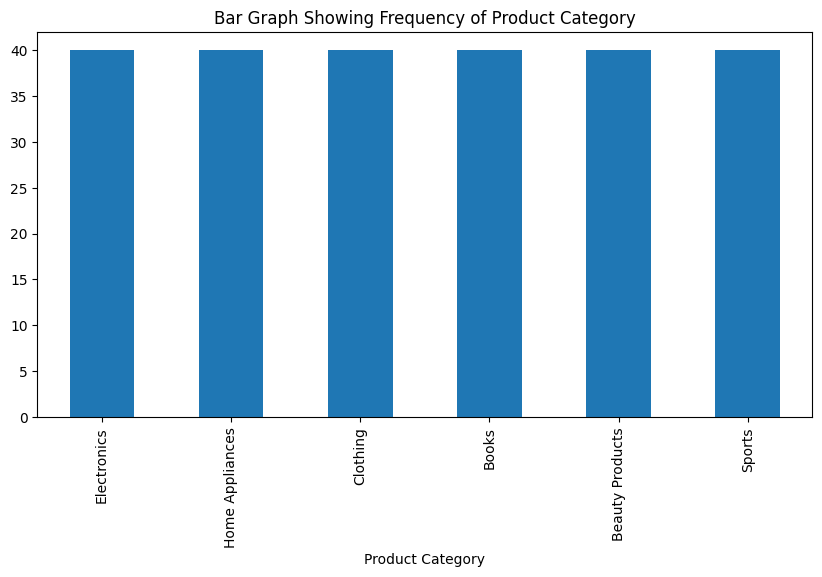

In [ ]:
plt.figure(figsize=(10,5))
df['Product Category'].value_counts().plot(kind='bar')
plt.title('Bar Graph Showing Frequency of Product Category')
plt.show()

### OR

In [ ]:
pc_df = df.groupby(by=['Product Category']).size().reset_index(name='Frequency')
pc_df

,Product Category,Frequency
0,Beauty Products,40
1,Books,40
2,Clothing,40
3,Electronics,40
4,Home Appliances,40
5,Sports,40


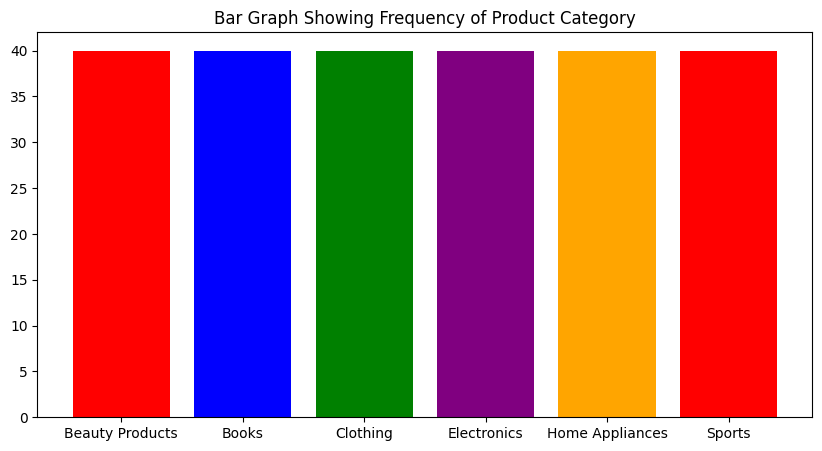

In [ ]:
colors = ['red', 'blue', 'green', 'purple', 'orange']
plt.figure(figsize=(10,5))
plt.bar(pc_df['Product Category'],pc_df['Frequency'],color=colors)
plt.title('Bar Graph Showing Frequency of Product Category')
plt.show()

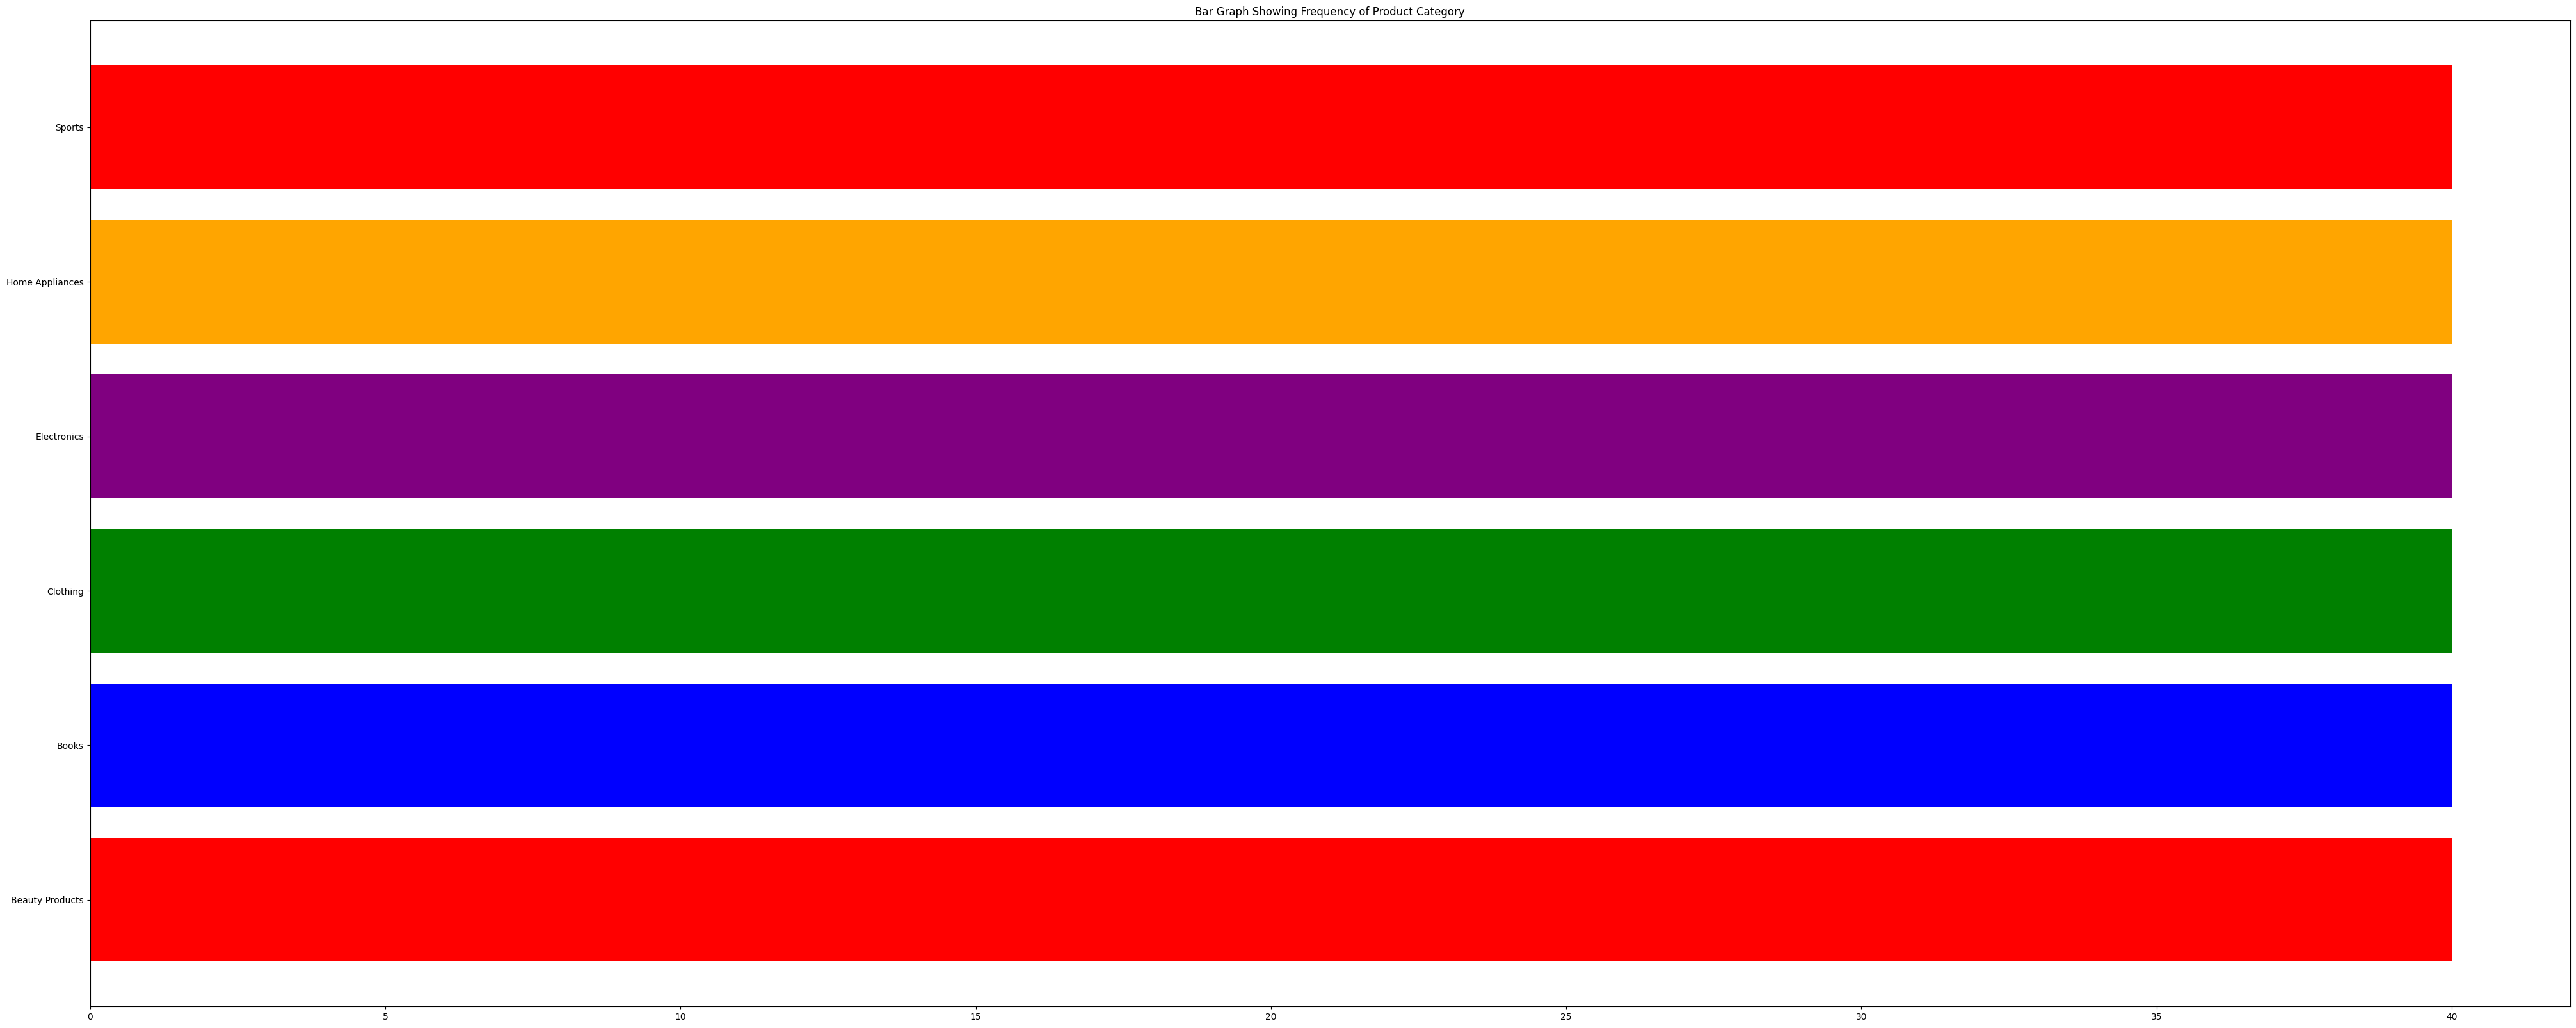

In [ ]:
colors = ['red', 'blue', 'green', 'purple', 'orange']
plt.figure(figsize=(50,20))
plt.barh(pc_df['Product Category'],pc_df['Frequency'],color=colors)
plt.title('Bar Graph Showing Frequency of Product Category')
plt.show()

### Task 1: Analyze the Frequency of `Region` and `Payment Method` and Plot the Bar Graph

In [ ]:
colors = ['purple', 'blue', 'pink', 'brown', 'orange']
plt.figure(figsize=(50, 20))
plt.barh(region_df['Region'], region_df['Frequency'], color=colors)
plt.title('Bar Graph Showing Frequency of Region')
plt.show()

In [ ]:
df.columns

Index(['Transaction ID', 'Date', 'Product Category', 'Product Name',
       'Units Sold', 'Unit Price', 'Total Revenue', 'Region',
       'Payment Method'],
      dtype='object')

We can also use **Pie Chart** to visualize the Categorical Data

The pie chart is one of the most commonly used charts when we need to display percentages or frequencies and relative frequencies.

In [ ]:
sls_cat_df=df.groupby(by=['Product Category']).agg({'Total Revenue':'sum'}).reset_index()
sls_cat_df=sls_cat_df.sort_values(by=['Total Revenue'],ascending=False)
sls_cat_df

,Product Category,Total Revenue
3,Electronics,34982.41
4,Home Appliances,18646.16
5,Sports,14326.52
2,Clothing,8128.93
0,Beauty Products,2621.90
1,Books,1861.93


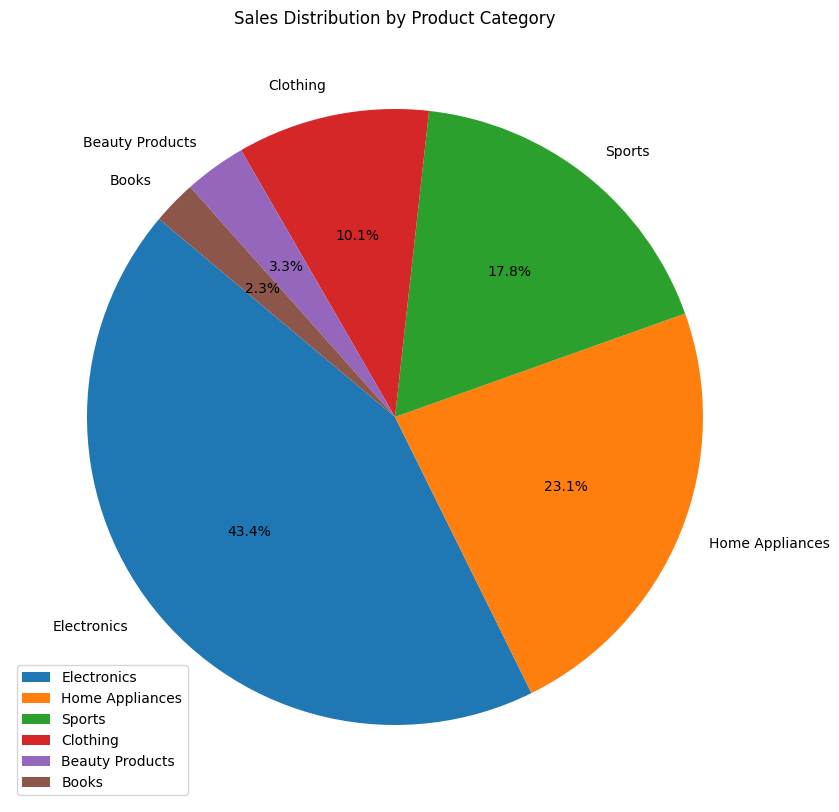

In [ ]:
plt.figure(figsize=(20,10))
plt.pie(sls_cat_df['Total Revenue'],labels=sls_cat_df['Product Category'],autopct='%1.1f%%', startangle=140)
plt.title('Sales Distribution by Product Category')
plt.legend()
plt.show()

## Describing Numerical Data

### Histogram

A histogram is a graph of grouped data in a frequency distribution table with equal class widths. It displays class boundaries on the horizontal axis and frequencies, relative frequencies, or percentages on the vertical axis.s.

Text(0.5, 0, 'Total Revenue')

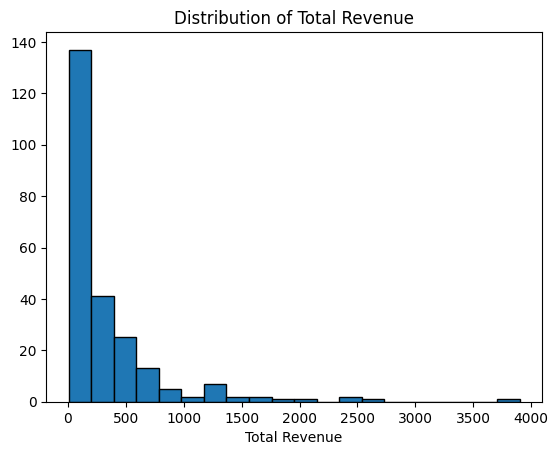

In [ ]:
plt.hist(df['Total Revenue'],bins=20, edgecolor='black')
plt.title('Distribution of Total Revenue')
plt.xlabel('Total Revenue')

### Task 2 Create a Histogram and Analyze the Distribution of `Unit Price`

In [ ]:
plt.hist(df['Unit Price'], bins = 20 , edgecolor = 'black')
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')

## Measures of Central Tendency
A measure of central tendency is an important aspect of quantitative data. It is an estimate of a “typical” value. 
Te mean, median, and mode are three ways to measure central tendencye.

### Mean
The mean is the average of the data. 
Let ${x_1,x_2...x_n}$ be our sample. The sample mean is usually denoted by $\bar{x}$.

$$\bar{x}=\sum_{i=1}^{n}\frac{x_i}{n}=\frac{1}{n}\sum_{i=1}^{n}x_i$$

Where $x_i$ are the measurements and $n$ is the sample size


The population mean is usually denoted by $\mu$. 
$$\bar{x}=\sum_{i=1}^{n}\frac{x_i}{N}=\frac{1}{N}\sum_{i=1}^{N}x_i$$
$N$ is the population size
The sample mean is a statistic and a population mean is a parameter

#### Calculation of Mean

In [ ]:
df['Total Revenue'].mean()

np.float64(335.699375)

In [ ]:
df.groupby(by=['Payment Method']).agg({'Units Sold':'mean','Total Revenue':'mean'}).reset_index()

,Payment Method,Units Sold,Total Revenue
0,Credit Card,2.233333,426.423833
1,Debit Card,3.625000,203.223250
2,PayPal,1.312500,265.850750


### Median

    The median is the middle value of the ordered data.

The most important step in finding the median is to first order the data from smallest to largest.

Steps to finding the median for a set of data:
1. Arrange the data in increasing order, i.e. smallest to largest.
2. Find the location of the median in the ordered data by $\frac{n+1}{2}$, where n is the sample size.
3. The value that represents the location found in Step 2 is the median.

**Note**
If the sample size is an odd number then the location point will produce a median that is an observed value. If the sample size is an even number, then the location will require one to take the mean of two numbers to calculate the median. The result may or may not be an observed value

In [ ]:
df['Total Revenue'].median()

np.float64(179.97)

In [ ]:
df.groupby(by=['Payment Method']).agg({'Units Sold':'median','Total Revenue':'median'}).reset_index()

,Payment Method,Units Sold,Total Revenue
0,Credit Card,2.0,214.975
1,Debit Card,3.0,179.970
2,PayPal,1.0,115.000


### Mode
The mode is the value that occurs most often in the data. It is important to note that there may be more than one mode in the dataset. 

In [ ]:
df['Total Revenue'].mode()

0    299.99
Name: Total Revenue, dtype: float64

When one has very skewed data, it is better to use the median as measure of central tendency since the median is not much affected by extreme values. 

### Task 3: Find Mean,Median and Mode for `Units Sold`, `Unit Price`, and `Total Revenue`. Also compute the Mean, Median and Mode of these variables for each values of `Product Category` and `Total Revenue` and compare it with overall values

In [ ]:
# Your Code Goes Here

### Measures of Position

While measures of central tendency are important, they do not tell the whole story. There are two other types of measures, measures of position and variability, that help paint a more concise picture of what is going on in the data. In this section, we will consider the measures of position. Measures of position give a range where a certain percentage of the data fall. The measures we consider here are percentiles and quartiles.

#### Percentiles
The $p^{th}$ percentile of the data set is a measurement such that after the data are ordered from smallest to largest, at most, p% of the data are at or below this value and at most, (100 - p)% at or above it.

The median is the value where fifty percent or the data values fall at or below it. Therefore, the median is the 50th percentile.

We can find any percentile we wish. There are two other important percentiles. The 25th percentile, typically denoted, `Q1`, and the 75th percentile, typically denoted as `Q3`. `Q1` is commonly called the **lower quartile** and `Q3` is commonly called the **upper quartile**.

![Q1, Median and Q3](images/position.png)

To compute the Q1 and Q3 we can follow the steps below
1. Arrange the Data in Ascending order
2. Find the Location of desired quartile
   $$Q_1=\frac{n+1}{4}$$
   $$Q_3=\frac{3(n+1)}{4}$$
3. Find the value in that position for the ordered data.

In [ ]:
# Calculate Q1 and Q3
q1 = df['Total Revenue'].quantile(0.25)
q3 = df['Total Revenue'].quantile(0.75)

print("Q1:", q1)
print("Q3:", q3)
print(f"The IQR is {q3-q1}")

Q1: 62.965
Q3: 399.225
The IQR is 336.26


In [ ]:
df['Total Revenue']

0      1999.98
1       499.99
2       209.97
3        63.96
4        89.99
        ...   
235     159.99
236     270.00
237      32.97
238      55.00
239      59.98
Name: Total Revenue, Length: 240, dtype: float64

###  The Five Number Summary
A helpful summary of the data is called the five number summary. The five number summary consists of five values:
1. The minimum
2. The lower quartile (Q1),
3. The median (also known as Q2)
4. The upper quartile (Q3)
5.  The maximum

We can visualize the Five Number Summary using the Box Plot

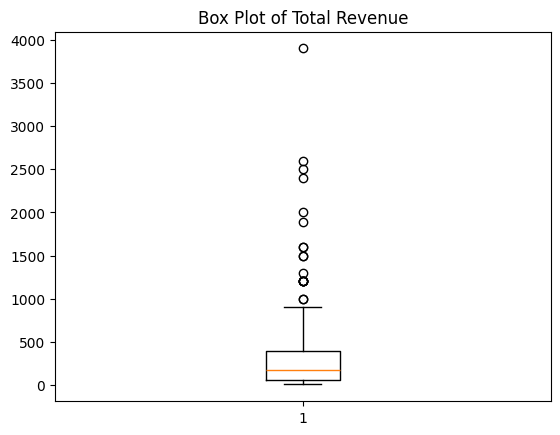

In [ ]:
plt.boxplot(df['Total Revenue'])
plt.title('Box Plot of Total Revenue')
plt.show()

The dots we are seeing are outliers. We use following equations to determine outliers

Anything above ${Q_3}+(1.5*IQR)$ is an outlier

Anything below $Q1-(1.5*IQR)$ is an outlier

$IQR = {Q_3}-{Q_1}$

### Task 4: Compute Five Number Summary of Numerical Values in the Dataset and Plot the Box Plot

In [ ]:
# Your Code Goes Here

## Measures of Variability (Measure of Dispersion)

There are many ways to describe variability or spread including:
1. Range
2. Interquartile range (IQR)
3. Variance and Standard Deviation

**Range**: The range is the difference in the maximum and minimum values of a data set. The maximum is the largest value in the dataset and the minimum is the smallest value. The range is easy to calculate but it is very much affected by extreme values.
$$Range = maximum-minimum$$
**Interquartile Range (IQR)**
The interquartile range is the difference between upper and lower quartiles and denoted as IQR.
$$IQR = {Q_3}-{Q_1}$$

**Variance** is   the average squared distance from the mean 

$$s^2=\frac{\sum_{i=1}^{N}(x_i-\bar{x}^2)}{n}$$
where $\bar{x}$ is the sample mean and n is the sample size

In [ ]:
df['Total Revenue'].var()

np.float64(236005.9816778504)

In [ ]:
df['Total Revenue'].mean()

np.float64(335.699375)

**Standard Deviation**
The standard deviation is a measure of the amount of variation or dispersion in a set of values. It quantifies how spread out the values in a dataset are around the mean (average) of the dataset.

$$s=\sqrt{s}$$

Since the standard deviation is in the same units as the original data, it is easier to understand and interpret compared to the variance.

In [ ]:
df['Total Revenue'].std()

np.float64(485.8044685651321)

**Coefficient of Variation**

Above we considered three measures of variation: Range, IQR, and Variance (and its square root counterpart - Standard Deviation). These are all measures we can calculate from one quantitative variable e.g. height, weight. But how can we compare dispersion (i.e. variability) of data from two or more distinct populations that have vastly different means?

A popular statistic to use in such situations is the Coefficient of Variation or CV. This is a unit-free statistic and one where the higher the value the greater the dispersion. The calculation of CV is:

$$CV=\frac{Standard Deviation}{Mean}$$

In [ ]:
# Calculate the mean
mean = df['Total Revenue'].mean()

# Calculate the standard deviation
std_dev = df['Total Revenue'].std()

# Calculate the Coefficient of Variation (CV)
cv = std_dev / mean

print("Mean:", mean)
print("Standard Deviation:", std_dev)
print("Coefficient of Variation (CV):", cv)

Mean: 335.699375
Standard Deviation: 485.8044685651321
Coefficient of Variation (CV): 1.4471414150387742


### Task 4: Compute the CV for Total Revenue for each value of `Payment Method`

## Analysis Relationship Between Two Variables

### Scatter Plot

An effective way to represent the relationship between two variables is by using a scatter plot.

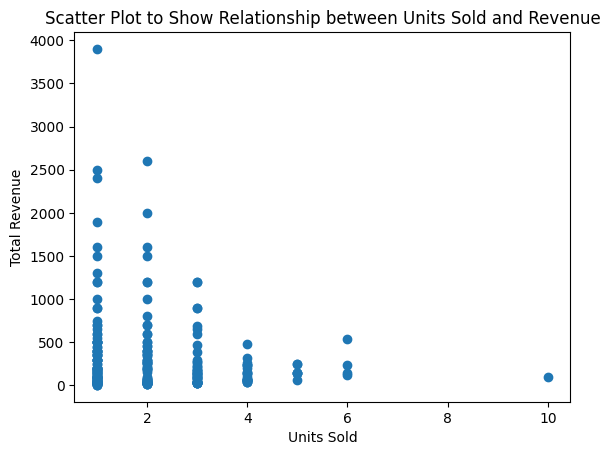

In [ ]:
plt.scatter(df['Units Sold'],df['Total Revenue'])
plt.xlabel('Units Sold')
plt.ylabel('Total Revenue')
plt.title('Scatter Plot to Show Relationship between Units Sold and Revenue')
plt.show()

### Line Plot

We can use the line plot to show the trend of a variable with time.

In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
daily_sls_df = df.groupby(by=['Date']).agg({'Total Revenue':'sum'}).reset_index()

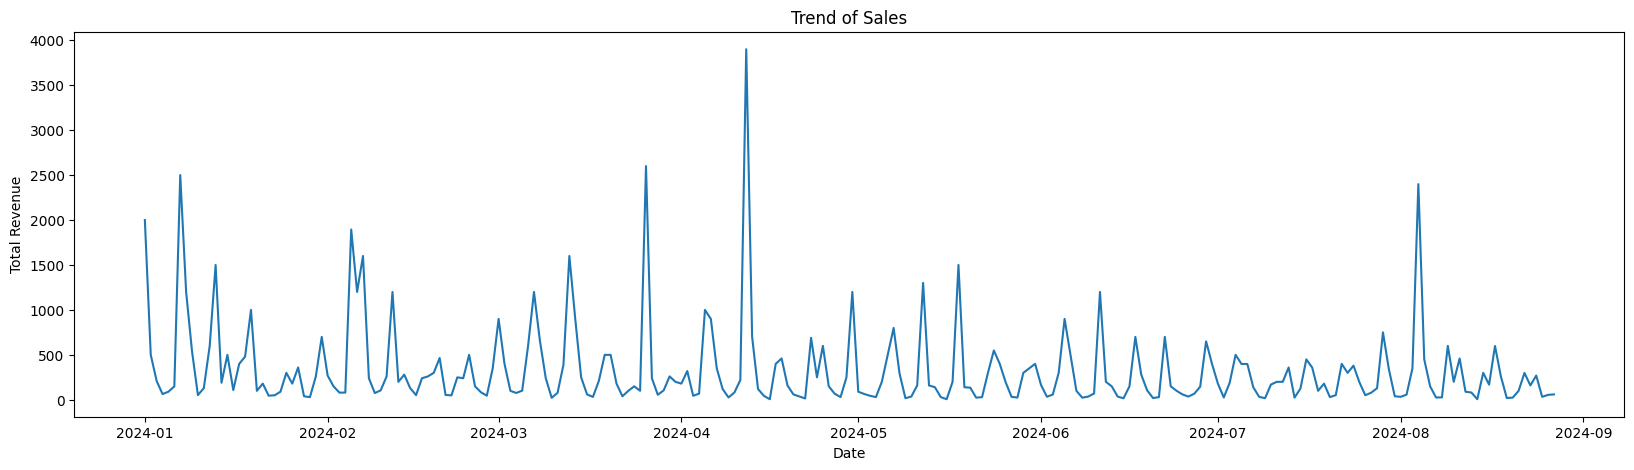

In [ ]:
plt.figure(figsize=(20,5))
plt.plot(daily_sls_df['Date'],daily_sls_df['Total Revenue'])
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.title('Trend of Sales')
plt.show()

### Covariance 
Covariance is a measure of the joint variability of two random variables. The sign of covariance shows the tendency in the linear relationship between the variables.
* Positive covariance: if the larger value of one variable corresponds with the larger values of other
* 
Negative covariance: fethe  larger value of one variable corresposnd with the smaller values of other

$$cov(x,y)=\frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{n-1}$$

In [ ]:
df[['Total Revenue','Units Sold']].cov()

,Total Revenue,Units Sold
Total Revenue,236005.981678,-109.956428
Units Sold,-109.956428,1.748884


### Correlation

If we want to provide a measure of the strength of the linear relationship between two quantitative variables, a good way is to report the correlation coefficient between them.

The sample correlation coefficient is typically denoted as $r$ It is also known as Pearson’s The population correlation coefficient is generally denoted as $\rho$, pronounced rho

$$r=\frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2}\sqrt{\sum(y_i-\bar{y})^2}}$$

#### Properties for Correlation Coefficient $r$

1. $-1<=r<=1$ $r$ takes a value between -1 and 1 inclusive
2. The sign of the correlation provides the direction of the linear relationship. The sign indicates whether the two variables are positively or negatively related.
3. A correlation of 0 means there is no linear relationship.
4. 
There are no units attached to$r$ 5. .
 As the magnitude $r$  
 approaches 1, the stronger the linear relationsh6. ip.
es the magnitud$r$ of 
 approaches 0, the weaker the linear relationship.


In [ ]:
import matplotlib.pyplot as plt

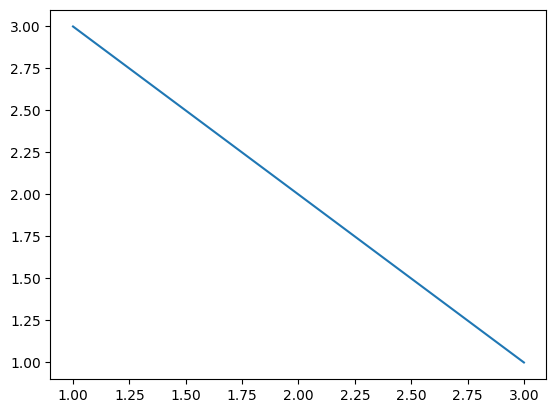

In [ ]:
plt.plot([1,2,3],[3,2,1])

In [ ]:
df[['Total Revenue','Units Sold']].corr()

,Total Revenue,Units Sold
Total Revenue,1.000000,-0.171151
Units Sold,-0.171151,1.000000


In [ ]:
df

NameError: name 'df' is not defined

In [ ]:
import seaborn as sns

In [ ]:
df[['Total Revenue','Units Sold']].corr()

NameError: name 'df' is not defined

<Axes: >

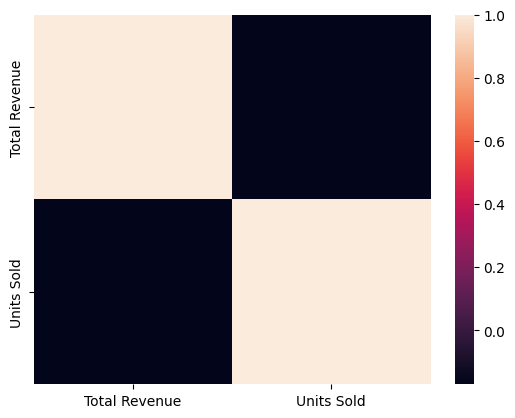

In [ ]:
sns.heatmap(df[['Total Revenue','Units Sold']].corr())

### Task 5: Find the Covariance and Correlation coefficient Between Numerical Variables in the dataset 

### Task 6: Download a dataset [Credit Card Eligibility Data: Determining Factors](https://www.kaggle.com/datasets/rohit265/credit-card-eligibility-data-determining-factors) and Perform Similar Analysis as we have done in this exercise

Now we want to know what is the effect of a unit change in one variable(independent variable) in another variable(dependent variable), what should we do? The Answer is **Linear Regression** 